# 2.6.1 A Simple Example Tossing Coins

In [1]:
%matplotlib inline
import random
import torch
from torch.distributions.multinomial import Multinomial
from d2l import torch as d2l

In [84]:
num_tosses = 1000
head = sum([random.random() > 0.5 for _ in range(num_tosses)])
tails = num_tosses - head
print(f"Number of heads: {head}, Number of tails: {tails}")

Number of heads: 507, Number of tails: 493


In [96]:
fair_probs = torch.tensor([0.5, 0.5])
Multinomial(1000, fair_probs).sample()

tensor([491., 509.])

In [97]:
Multinomial(1000, fair_probs).sample() / 1000

tensor([0.5200, 0.4800])

In [98]:
counts = Multinomial(100000, fair_probs).sample()
counts /100000

tensor([0.5016, 0.4984])

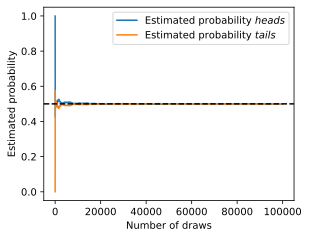

In [104]:
counts = Multinomial(1, fair_probs).sample((100000,))
cum_counts = counts.cumsum(dim=0)
estimates = cum_counts / cum_counts.sum(dim=1, keepdims=True)
estimates = estimates.numpy()

d2l.set_figsize((4.5 ,3.5))
d2l.plt.plot(estimates[:, 0], label="Estimated probability $heads$")
d2l.plt.plot(estimates[:, 1], label="Estimated probability $tails$")
d2l.plt.axhline(y=0.5, color='black', linestyle='dashed')
d2l.plt.xlabel('Number of draws')
d2l.plt.ylabel('Estimated probability')
d2l.plt.legend()